In [1]:
!pip install tf-kan-latest
!pip install numpy --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 84.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 require

# Import

In [2]:
from __future__ import annotations

import os
import random
import shutil
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, metrics, models, regularizers
from tensorflow.keras.callbacks import (
    CSVLogger,
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    Callback
)
from tfkan.layers import DenseKAN as KANLinear

import matplotlib.pyplot as plt
import seaborn as sns

2026-06-11 14:52:42.785864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781189562.973985      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781189563.028739      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781189563.462282      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781189563.462331      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781189563.462334      23 computation_placer.cc:177] computation placer alr

# Config

In [3]:
@dataclass(frozen=True)
class Config:
    dataset_path: str = "/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification"
    split_dir: str = "/kaggle/working/split_dataset"
    image_size: tuple[int, int] = (128, 128)
    batch_size: int = 32
    epochs: int = 100
    seed: int = 42

    # Targeted augmentation
    # Jumlah sampel target per kelas di train set.
    # Kelas yang sudah >= nilai ini tidak disentuh.
    # Set ke 0 untuk skip augmentasi offline.
    targeted_aug_target: int = 0  # 0 = auto: samakan ke kelas terbesar

    # Mixup — online augmentation untuk menutup gap overfitting
    # alpha=0.2 adalah nilai standard. Set ke 0.0 untuk nonaktifkan.
    mixup_alpha: float = 0.2

    # L2 regularization pada semua Conv2D
    l2_reg: float = 1e-4

    # Optimizer
    learning_rate: float = 1e-4
    epsilon: float = 1e-07

    # Callbacks
    lr_patience: int = 8
    lr_factor: float = 0.3
    lr_min: float = 1e-6

    # KAN
    kan_units: int = 256
    kan_grid_size: int = 3

    model_name: str = "CNN_KAN"

    @property
    def input_shape(self) -> tuple[int, int, int]:
        return (*self.image_size, 3)

CFG = Config()

## Set Seed

In [4]:
if CFG.seed:
    np.random.seed(CFG.seed)
    random.seed(CFG.seed)
    tf.random.set_seed(CFG.seed)
    print(f"Setup seed {CFG.seed} Done !")

Setup seed 42 Done !


# Dataset

## Split Data
Split data menggunakan proporsi 80% untuk train, 10% untuk val, dan 10% untuk test

In [5]:
def prepare_split_dirs(cfg: Config) -> tuple[str, str, str]:
    """Buat struktur folder 
        split_dir / <train|val|test> / <class> / <file>.

    Menggunakan symlink agar tidak menduplikasi file di disk.
    Jika split_dir sudah ada, langsung pakai (skip re-split).

    Returns:
        (train_dir, val_dir, test_dir)
    """
    train_dir = os.path.join(cfg.split_dir, "train")
    val_dir   = os.path.join(cfg.split_dir, "val")
    test_dir  = os.path.join(cfg.split_dir, "test")

    if os.path.exists(cfg.split_dir):
        print(f"[split] Folder split sudah ada, skip re-split: {cfg.split_dir}")
        return train_dir, val_dir, test_dir

    print(f"[split] Membuat split di: {cfg.split_dir}")
    classes = sorted(
        name for name in os.listdir(cfg.dataset_path)
        if os.path.isdir(os.path.join(cfg.dataset_path, name))
    )

    for class_name in classes:
        src_class_dir = os.path.join(cfg.dataset_path, class_name)
        all_files = [
            f for f in os.listdir(src_class_dir)
            if not f.startswith(".")
        ]

        # 80 / 10 / 10 stratified split
        train_files, temp_files = train_test_split(
            all_files, test_size=0.20, random_state=cfg.seed
        )
        val_files, test_files = train_test_split(
            temp_files, test_size=0.50, random_state=cfg.seed
        )

        for split_name, file_list in (
            ("train", train_files),
            ("val",   val_files),
            ("test",  test_files),
        ):
            dst_dir = os.path.join(cfg.split_dir, split_name, class_name)
            os.makedirs(dst_dir, exist_ok=True)
            for fname in file_list:
                src = os.path.join(src_class_dir, fname)
                dst = os.path.join(dst_dir, fname)
                # Symlink → nol overhead disk
                if not os.path.exists(dst):
                    os.symlink(src, dst)

    print("[split] Selesai.")
    return train_dir, val_dir, test_dir

In [6]:
train_dir, val_dir, test_dir = prepare_split_dirs(CFG)

[split] Membuat split di: /kaggle/working/split_dataset
[split] Selesai.


## Targeted Augmentation
untuk penyeimbangan data menggunakan Targeted Augmentation dan targetnya hanya untuk train. Val dan test TIDAK disentuh sama sekali.

In [7]:
def _augment_image(img: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Terapkan satu set transformasi acak pada satu gambar (numpy, uint8).

    Transformasi yang digunakan:
    - Horizontal flip
    - Rotasi ±15°
    - Translasi ±10% width/height
    - Zoom in/out ±10%
    - Brightness jitter ±20%

    Args:
        img: Array uint8 shape (H, W, 3), BGR atau RGB (tidak berpengaruh
             karena transformasinya spatial + brightness).
        rng: numpy Generator untuk reproduktibilitas.

    Returns:
        Gambar hasil augmentasi, shape dan dtype sama dengan input.
    """
    h, w = img.shape[:2]

    # 1. Horizontal flip (50%)
    if rng.random() > 0.5:
        img = cv2.flip(img, 1)

    # 2. Rotasi ±15°
    angle = rng.uniform(-15, 15)
    m_rot = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(img, m_rot, (w, h),
                         flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_REFLECT_101)

    # 3. Translasi ±10%
    tx = rng.uniform(-0.1, 0.1) * w
    ty = rng.uniform(-0.1, 0.1) * h
    m_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, m_trans, (w, h),
                         borderMode=cv2.BORDER_REFLECT_101)

    # 4. Zoom ±10% (crop tengah lalu resize balik)
    scale = rng.uniform(0.9, 1.1)
    new_h, new_w = int(h * scale), int(w * scale)
    if scale > 1.0:                      # zoom in → crop
        y0 = (new_h - h) // 2
        x0 = (new_w - w) // 2
        img_resized = cv2.resize(img, (new_w, new_h),
                                 interpolation=cv2.INTER_LINEAR)
        img = img_resized[y0:y0 + h, x0:x0 + w]
    else:                                # zoom out → pad + resize
        img_resized = cv2.resize(img, (new_w, new_h),
                                 interpolation=cv2.INTER_LINEAR)
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        img = cv2.copyMakeBorder(
            img_resized, pad_h, h - new_h - pad_h,
            pad_w, w - new_w - pad_w,
            cv2.BORDER_REFLECT_101,
        )

    # 5. Brightness jitter ±20%
    factor = rng.uniform(0.8, 1.2)
    img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

    return img


def apply_targeted_augmentation(
    train_dir: str,
    image_size: tuple[int, int],
    target_per_class: int,
    seed: int,
) -> None:
    """Perbanyak gambar kelas minoritas di train_dir sampai target_per_class.

    File augmentasi ditulis langsung ke folder kelas di train_dir
    dengan nama `aug_<N>_<nama_asli>.png`. Fungsi ini idempoten:
    jika dipanggil ulang, hanya menambah kekurangan (tidak duplikasi).

    Args:
        train_dir        : Path ke split_dir/train/.
        image_size       : (W, H) untuk resize hasil augmentasi.
        target_per_class : Jumlah sampel target. Kelas yang sudah >=
                           nilai ini dilewati. Jika 0, otomatis pakai
                           jumlah sampel kelas terbesar.
        seed             : Seed untuk reproduktibilitas.
    """
    rng = np.random.default_rng(seed)

    classes = sorted(
        c for c in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, c))
    )

    # Hitung jumlah file asli per kelas (sebelum augmentasi)
    original_counts: dict[str, int] = {}
    for c in classes:
        files = [
            f for f in os.listdir(os.path.join(train_dir, c))
            if not f.startswith("aug_")          # abaikan file augmentasi lama
            and not f.startswith(".")
        ]
        original_counts[c] = len(files)

    # Tentukan target
    resolved_target = target_per_class if target_per_class > 0 \
        else max(original_counts.values())

    print(f"[aug] Target per kelas : {resolved_target}")
    print(f"[aug] Jumlah asli      : {original_counts}")

    for class_name in classes:
        class_dir = os.path.join(train_dir, class_name)
        orig_count = original_counts[class_name]

        if orig_count >= resolved_target:
            print(f"[aug] {class_name}: {orig_count} >= {resolved_target}, skip.")
            continue

        # File asli saja sebagai sumber augmentasi
        source_files = [
            f for f in os.listdir(class_dir)
            if not f.startswith("aug_") and not f.startswith(".")
        ]

        # Cek berapa yang sudah ditulis sebelumnya
        existing_aug = len([
            f for f in os.listdir(class_dir) if f.startswith("aug_")
        ])
        need = resolved_target - orig_count - existing_aug

        if need <= 0:
            print(f"[aug] {class_name}: augmentasi sudah cukup, skip.")
            continue

        print(f"[aug] {class_name}: perlu {need} gambar baru "
              f"(ada {orig_count} asli + {existing_aug} aug).")

        generated = 0
        while generated < need:
            src_name = source_files[rng.integers(len(source_files))]
            src_path = os.path.join(class_dir, src_name)

            img = cv2.imread(src_path)
            if img is None:
                continue
            img = cv2.resize(img, image_size)
            img_aug = _augment_image(img, rng)

            out_name = f"aug_{existing_aug + generated:05d}_{src_name}"
            # Pastikan ekstensi .png agar tidak bergantung pada format asli
            out_name = Path(out_name).with_suffix(".png").name
            out_path = os.path.join(class_dir, out_name)

            cv2.imwrite(out_path, img_aug)
            generated += 1

        print(f"[aug] {class_name}: +{generated} gambar ditulis.")

    print("[aug] Targeted augmentation selesai.")

In [8]:
apply_targeted_augmentation(
    train_dir=train_dir,
    image_size=CFG.image_size,
    target_per_class=CFG.targeted_aug_target,  # 0 = auto ke kelas terbesar
    seed=CFG.seed,
)

[aug] Target per kelas : 4260
[aug] Jumlah asli      : {'battery': 756, 'biological': 788, 'brown-glass': 485, 'cardboard': 712, 'clothes': 4260, 'green-glass': 503, 'metal': 615, 'paper': 840, 'plastic': 692, 'shoes': 1581, 'trash': 557, 'white-glass': 620}
[aug] battery: perlu 3504 gambar baru (ada 756 asli + 0 aug).
[aug] battery: +3504 gambar ditulis.
[aug] biological: perlu 3472 gambar baru (ada 788 asli + 0 aug).
[aug] biological: +3472 gambar ditulis.
[aug] brown-glass: perlu 3775 gambar baru (ada 485 asli + 0 aug).
[aug] brown-glass: +3775 gambar ditulis.
[aug] cardboard: perlu 3548 gambar baru (ada 712 asli + 0 aug).
[aug] cardboard: +3548 gambar ditulis.
[aug] clothes: 4260 >= 4260, skip.
[aug] green-glass: perlu 3757 gambar baru (ada 503 asli + 0 aug).
[aug] green-glass: +3757 gambar ditulis.
[aug] metal: perlu 3645 gambar baru (ada 615 asli + 0 aug).
[aug] metal: +3645 gambar ditulis.
[aug] paper: perlu 3420 gambar baru (ada 840 asli + 0 aug).
[aug] paper: +3420 gambar ditu

## Build Datasets

In [9]:
def build_datasets(
    train_dir: str,
    val_dir: str,
    test_dir: str,
    cfg: Config,
) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, list[str]]:
    """Bangun pipeline baca-dari-disk menggunakan image_dataset_from_directory.

    Tidak ada numpy array besar di memori — setiap batch dibaca saat dibutuhkan.

    Returns:
        (train_ds, val_ds, test_ds, class_names)
    """
    common_kwargs = dict(
        image_size=cfg.image_size,
        batch_size=cfg.batch_size,
        label_mode="categorical",
        seed=cfg.seed,
    )

    AUTOTUNE = tf.data.AUTOTUNE

    def rescale(x: tf.Tensor, y: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
        return tf.cast(x, tf.float32) / 255.0, y

    # Simpan raw dataset dulu agar class_names masih accessible
    raw_train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, shuffle=True, **common_kwargs
    )
    raw_val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, shuffle=False, **common_kwargs
    )
    raw_test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir, shuffle=False, **common_kwargs
    )

    # Ambil class_names SEBELUM .map()/.prefetch() — attribute hilang setelahnya
    class_names: list[str] = raw_train_ds.class_names
    print(f"[pipeline] Kelas: {class_names}")

    train_ds = raw_train_ds.map(rescale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds   = raw_val_ds.map(rescale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    test_ds  = raw_test_ds.map(rescale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

In [10]:
# 3. Pipeline baca dari disk
train_ds, val_ds, test_ds, class_names = build_datasets(
    train_dir, val_dir, test_dir, CFG
)
num_classes = len(class_names)

Found 51120 files belonging to 12 classes.


I0000 00:00:1781189746.332146      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 1550 files belonging to 12 classes.
Found 1556 files belonging to 12 classes.
[pipeline] Kelas: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## Mixup Augmentation

In [11]:
def apply_mixup(
    train_ds: tf.data.Dataset,
    alpha: float,
    seed: int,
) -> tf.data.Dataset:
    """Terapkan Mixup augmentation pada train_ds (batch-level, online).

    Mixup mencampur dua gambar dan label secara proporsional:
        x_mix = λ·x1 + (1−λ)·x2
        y_mix = λ·y1 + (1−λ)·y2

    λ diambil dari distribusi Beta(alpha, alpha). Label jadi soft label
    sehingga model tidak bisa "overcommit" ke satu kelas — ini yang
    efektif menutup gap train-val.

    Hanya diterapkan pada train_ds. Val dan test tidak disentuh.

    Args:
        train_ds : Dataset yang sudah di-rescale dan di-batch.
        alpha    : Parameter distribusi Beta. 0.2 adalah nilai umum.
                   Semakin besar → campuran lebih agresif.
        seed     : Seed untuk reproduktibilitas.

    Returns:
        Dataset baru dengan mixup diterapkan per batch.
    """
    if alpha <= 0.0:
        print("[mixup] alpha=0, mixup dinonaktifkan.")
        return train_ds

    print(f"[mixup] Diterapkan dengan alpha={alpha}")

    @tf.function
    def mixup_batch(
        x: tf.Tensor, y: tf.Tensor
    ) -> tuple[tf.Tensor, tf.Tensor]:
        batch_size = tf.shape(x)[0]

        # Ambil λ dari Beta(alpha, alpha) — satu nilai per gambar dalam batch
        lam = tf.cast(
            tf.random.stateless_gamma(
                shape=[batch_size],
                alpha=alpha,
                seed=(seed, seed + 1),
            ),
            tf.float32,
        )
        # Normalisasi ke [0,1] dengan max(λ, 1−λ) agar campuran tidak dominan satu sisi
        lam = lam / (lam + tf.random.stateless_gamma(
            shape=[batch_size],
            alpha=alpha,
            seed=(seed + 2, seed + 3),
        ))
        lam = tf.maximum(lam, 1.0 - lam)  # pastikan λ >= 0.5

        # Shuffle index untuk pasangan campuran
        indices = tf.random.shuffle(tf.range(batch_size))
        x2 = tf.gather(x, indices)
        y2 = tf.gather(y, indices)

        # Broadcast λ ke shape gambar dan label
        lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
        lam_y = tf.reshape(lam, [batch_size, 1])

        x_mix = lam_x * x + (1.0 - lam_x) * x2
        y_mix = lam_y * y + (1.0 - lam_y) * y2
        return x_mix, y_mix

    return train_ds.map(mixup_batch, num_parallel_calls=tf.data.AUTOTUNE)

In [12]:
# Mixup — hanya train_ds, val/test tidak disentuh
train_ds = apply_mixup(train_ds, alpha=CFG.mixup_alpha, seed=CFG.seed)

[mixup] Diterapkan dengan alpha=0.2


## Class Weight

In [13]:
def compute_class_weights_from_dir(
    train_dir: str,
    class_names: list[str],
) -> dict[int, float]:
    """Hitung class weight hanya dari jumlah file per kelas (tanpa baca pixel)."""
    counts = np.array([
        len(os.listdir(os.path.join(train_dir, c)))
        for c in class_names
    ], dtype=np.int64)

    # Rekonstruksi y_train sebagai array label (0,0,...,1,1,...) dari counts
    y_train = np.concatenate([
        np.full(cnt, i) for i, cnt in enumerate(counts)
    ])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(class_names)),
        y=y_train,
    )
    weight_dict = dict(enumerate(weights))
    print(f"[weights] {weight_dict}")
    return weight_dict

In [14]:
class_weight_dict = compute_class_weights_from_dir(train_dir, class_names)

[weights] {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0)}


## Augmentasi

In [15]:
augmentation_block =  models.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=10.0 / 360.0, fill_mode="nearest"),
        layers.RandomTranslation(
            height_factor=0.1, width_factor=0.1, fill_mode="nearest"
        ),
        layers.RandomZoom(height_factor=0.1, fill_mode="nearest"),
    ],
    name="augmentation",
)

# Model
## Build Model

In [16]:
def build_cnn_kan(
    input_shape: tuple[int, int, int],
    num_classes: int,
    kan_units: int,
    kan_grid_size: int,
    l2_reg: float = 1e-4,
    aug=None,
) -> models.Model:
    """CNN + 1 KANLinear classifier head dengan L2 regularization.

    Perubahan dari versi sebelumnya:
    - Semua Conv2D diberi kernel_regularizer=l2(l2_reg) untuk mengurangi
      kapasitas efektif model tanpa mengubah arsitektur.
    - Block 4: filter dikurangi 256→128, block 5: 512→256 agar model
      tidak terlalu besar untuk ukuran dataset TrashNet.
    """
    reg = regularizers.l2(l2_reg)
    aug_block = [aug] if aug else []

    return models.Sequential(
        [
            # Menyimpan augmentasi 
            *aug_block,

            # Block 1: 32
            layers.Conv2D(32, 3, padding="same", activation="swish",
                          kernel_regularizer=reg, input_shape=input_shape),
            layers.BatchNormalization(),
            layers.Conv2D(32, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.MaxPooling2D(2),
            layers.SpatialDropout2D(0.1),

            # Block 2: 64
            layers.Conv2D(64, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.BatchNormalization(),
            layers.Conv2D(64, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.MaxPooling2D(2),
            layers.SpatialDropout2D(0.2),

            # Block 3: 128
            layers.Conv2D(128, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.BatchNormalization(),
            layers.Conv2D(128, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.MaxPooling2D(2),
            layers.SpatialDropout2D(0.2),

            # Block 4: 128 (dikurangi dari 256 — dataset TrashNet tidak terlalu besar)
            layers.Conv2D(128, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.BatchNormalization(),
            layers.Conv2D(128, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.MaxPooling2D(2),
            layers.SpatialDropout2D(0.2),

            # Block 5: 256 (dikurangi dari 512), bottleneck 1×1
            layers.Conv2D(256, 3, padding="same", activation="swish",
                          kernel_regularizer=reg),
            layers.BatchNormalization(),
            layers.Conv2D(256, 1, padding="same", activation="swish",
                          kernel_regularizer=reg),

            layers.GlobalAveragePooling2D(),

            # Classifier head: 2 KANLinear + 1 Dense softmax
            KANLinear(kan_units, grid_size=kan_grid_size),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
 
            KANLinear(128, grid_size=kan_grid_size),
            layers.BatchNormalization(),
            layers.Dropout(0.2),

            layers.Dense(num_classes, activation="softmax"),
        ],
        name="CNN_KAN",
    )

## Setup Optimizer

In [17]:
# optimizer = tf.keras.optimizers.Adam(
#     learning_rate=CFG.learning_rate,
#     weight_decay=1e-4,
#     beta_1=0.9,
#     beta_2=0.999,
#     epsilon=CFG.epsilon,
# )

# optimizer=tf.keras.optimizers.RMSprop(
#     learning_rate=CFG.learning_rate,
#     rho=0.95,
#     epsilon=1e-07,
# )

optimizer=tf.keras.optimizers.Lion(
    learning_rate=CFG.learning_rate,
    beta_1=0.9,
    beta_2=0.99
)

## Build & Compile

In [18]:
# Build & compile
model = build_cnn_kan(
    input_shape=CFG.input_shape,
    num_classes=num_classes,
    kan_units=CFG.kan_units,
    kan_grid_size=CFG.kan_grid_size,
    l2_reg=CFG.l2_reg,
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        metrics.AUC(name="auc"),
    ],
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_KAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 16, 16, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 8, 8, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       295,16

 Total params: 1,637,164 (6.25 MB)

 Trainable params: 1,635,180 (6.24 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [19]:
# Build & compile + Augmentasi
model = build_cnn_kan(
    input_shape=CFG.input_shape,
    num_classes=num_classes,
    kan_units=CFG.kan_units,
    kan_grid_size=CFG.kan_grid_size,
    l2_reg=CFG.l2_reg,
    aug=augmentation_block,
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        metrics.AUC(name="auc"),
    ],
)

## Callback

In [20]:
import time

class TimeHistory(Callback):
    times = list()

    def on_train_begin(self, logs={}):
        self.times = [] # List untuk menyimpan waktu setiap epoch

    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time() # Catat waktu mulai

    def on_epoch_end(self, epoch, logs={}):
        waktu_epoch = time.time() - self.epoch_time_start # Hitung selisihnya
        self.times.append(waktu_epoch)

# 1. Inisialisasi Callback
time_callback = TimeHistory()

In [21]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=CFG.lr_factor,
        patience=CFG.lr_patience,
        min_lr=CFG.lr_min,
        verbose=1,
    ),
    ModelCheckpoint(
        f"best_{CFG.model_name}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    CSVLogger(f"training_log_{CFG.model_name}.csv", append=False),
    time_callback,
]

# Train

In [22]:
%%time

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.epochs,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
)

Epoch 1/100


E0000 00:00:1781189761.584123      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_KAN_1/spatial_dropout2d_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1781189763.610745      85 cuda_dnn.cc:529] Loaded cuDNN version 91002


1598/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3290 - auc: 0.6588 - loss: 2.2878
Epoch 1: val_accuracy improved from None to 0.51097, saving model to best_CNN_KAN.keras

Epoch 1: finished saving model to best_CNN_KAN.keras
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 118s 65ms/step - accuracy: 0.4042 - auc: 0.6909 - loss: 2.0433 - val_accuracy: 0.5110 - val_auc: 0.8958 - val_loss: 1.6052 - learning_rate: 1.0000e-04
Epoch 2/100
1597/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5019 - auc: 0.7198 - loss: 1.7478
Epoch 2: val_accuracy improved from 0.51097 to 0.58516, saving model to best_CNN_KAN.keras

Epoch 2: finished saving model to best_CNN_KAN.keras
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 102s 64ms/step - accuracy: 0.5132 - auc: 0.7229 - loss: 1.7090 - val_accuracy: 0.5852 - val_auc: 0.9328 - val_loss: 1.3083 - learning_rate: 1.0000e-04
Epoch 3/100
1597/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5475 - auc: 0.7304 - loss: 1.6194
Epoch 3: val_accuracy did not improve from 0.5851

# Evaluasi

In [23]:
def plot_metric(history: tf.keras.callbacks.History, metric: str) -> None:
    hist = history.history
    if metric not in hist:
        return
    train_vals = hist[metric]
    val_vals   = hist.get(f"val_{metric}", [])
    epoch_range = range(1, len(train_vals) + 1)
    display_name = metric.replace("_", " ").title()

    plt.figure(figsize=(8, 5))
    plt.plot(epoch_range, train_vals, label=f"Train {display_name}")
    if val_vals:
        plt.plot(epoch_range, val_vals, label=f"Val {display_name}")
    plt.title(f"Training vs Validation — {display_name}")
    plt.xlabel("Epoch")
    plt.ylabel(display_name)
    plt.legend(loc="upper right" if "loss" in metric else "lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"plot_{metric}.png")
    plt.show()


def evaluate_and_report(
    model: models.Model,
    test_ds: tf.data.Dataset,
    class_names: list[str],
) -> None:
    results = model.evaluate(test_ds, verbose=0)
    metric_names = ["loss", "accuracy", "auc"]
    print("\n--- Hasil Evaluasi Test Set ---")
    for name, val in zip(metric_names, results):
        if isinstance(val, (list, np.ndarray)):
            val = float(np.mean(val))
        print(f"  {name.capitalize():<12}: {val:.4f}")

    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    # Ambil label dari dataset (tidak perlu simpan y_test di RAM sejak awal)
    y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
    )
    plt.title("Confusion Matrix — Test Data")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("plot_confusion_matrix.png")
    plt.show()

## Plot

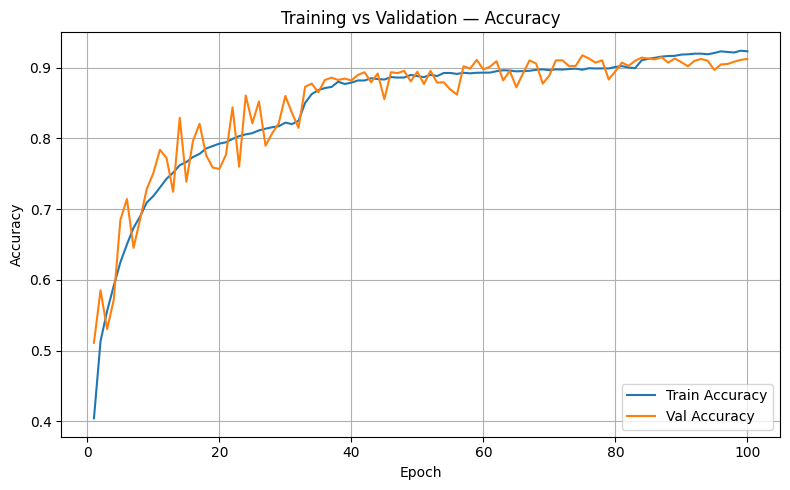

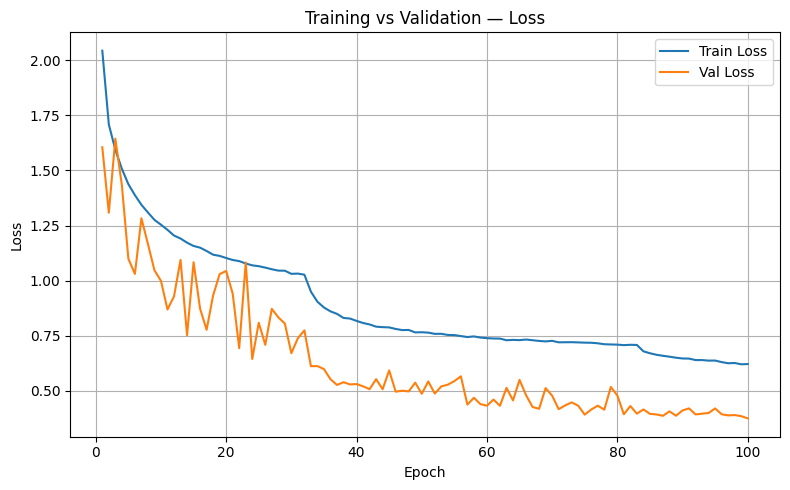

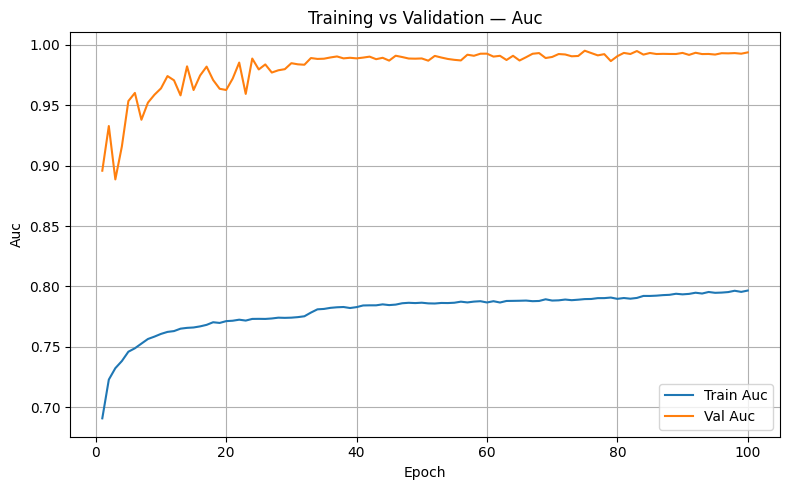

In [24]:
for metric in ("accuracy", "loss", "auc"):
    plot_metric(history, metric)


--- Hasil Evaluasi Test Set ---
  Loss        : 0.3959
  Accuracy    : 0.9075
  Auc         : 0.9918

--- Classification Report ---
              precision    recall  f1-score   support

     battery     0.9231    0.8842    0.9032        95
  biological     0.9278    0.9091    0.9184        99
 brown-glass     0.9818    0.8852    0.9310        61
   cardboard     0.9512    0.8667    0.9070        90
     clothes     0.8705    0.9962    0.9291       533
 green-glass     0.9500    0.9048    0.9268        63
       metal     0.9143    0.8312    0.8707        77
       paper     0.9176    0.7429    0.8211       105
     plastic     0.8919    0.7586    0.8199        87
       shoes     0.9372    0.9040    0.9203       198
       trash     0.9833    0.8429    0.9077        70
 white-glass     0.8889    0.9231    0.9057        78

    accuracy                         0.9075      1556
   macro avg     0.9281    0.8707    0.8967      1556
weighted avg     0.9106    0.9075    0.9060      1556



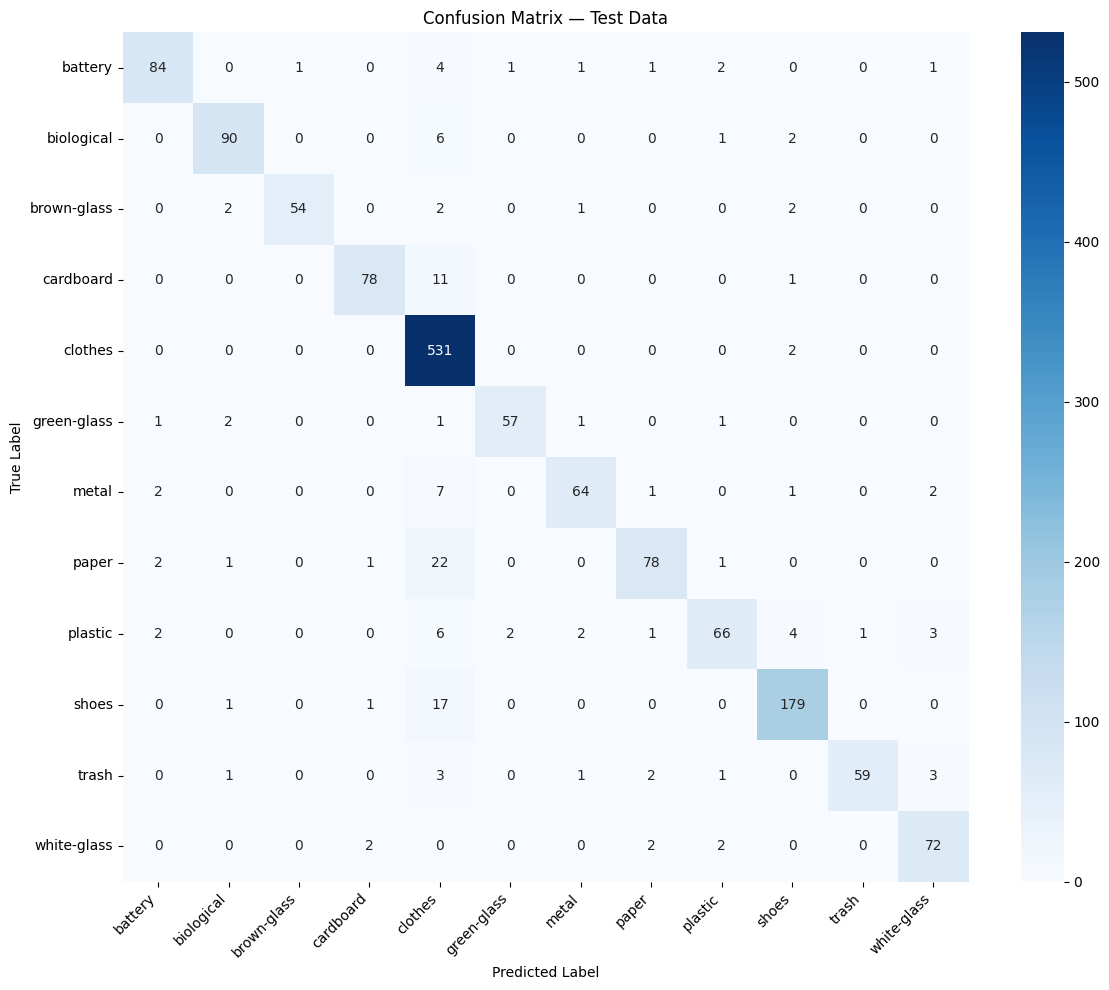

In [25]:
evaluate_and_report(model, test_ds, class_names)

## AUC

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


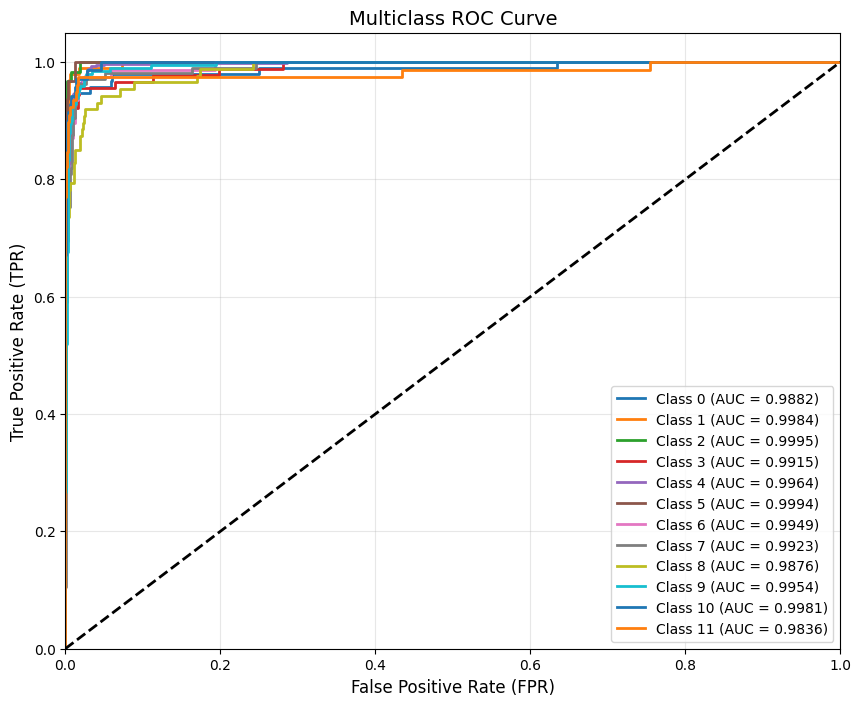

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical # Gunakan Keras Utilities

y_pred_probs = model.predict(test_ds)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Dapatkan jumlah kelas dari output arsitektur model Anda
n_classes = y_pred_probs.shape[1] 

if len(y_true.shape) == 1 or y_true.shape[1] == 1:
    # Memaksa array label dipecah menjadi jumlah kolom yang sama dengan n_classes
    y_true_bin = to_categorical(y_true, num_classes=n_classes)
else:
    y_true_bin = y_true 

plt.figure(figsize=(10, 8))

# Looping untuk menghitung AUC setiap kelas
for i in range(n_classes):
    # Sekarang dimensi y_true_bin dan y_pred_probs sudah dipastikan sama
    fpr, tpr, thresholds = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Multiclass ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.savefig("plot_AUC_tiap_class.png")
plt.show()

## Simpan

In [27]:
# 10. Simpan
model.save(f"{CFG.model_name}.keras")
print(f"[save] Model disimpan ke {CFG.model_name}.keras")

[save] Model disimpan ke CNN_KAN.keras


In [28]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops_native(model):
    """Menghitung FLOPs menggunakan profiler bawaan TensorFlow (Fixed for Augmentation)"""
    # Ambil input shape dari model, ubah ukuran batch menjadi 1
    input_signature = [tf.TensorSpec([1] + list(model.input_shape[1:]), model.inputs[0].dtype)]
    
    # Buat concrete function dan PAKSA masuk ke mode inference (training=False)
    @tf.function
    def forward_pass(inputs):
        return model(inputs, training=False) 
    
    concrete_func = forward_pass.get_concrete_function(*input_signature)
    
    # Bekukan graph
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    
    # Hitung FLOPs
    with tf.Graph().as_default() as graph:
        tf.import_graph_def(graph_def, name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        
        # Sembunyikan print out bawaan agar rapi
        opts['output'] = 'none' 
        
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
        return flops.total_float_ops

# 1. Hitung FLOPs untuk 1 gambar
flops_per_image = get_flops_native(model)

# 2. Hitung Total FLOS
epochs_run = len(history.history['loss']) 
steps_per_epoch = len(train_ds)      

# Ganti CFG.batch_size dengan 32 jika CFG tidak terdefinisi
total_images_processed = epochs_run * steps_per_epoch * CFG.batch_size 

# Total keseluruhan (1x Forward, 2x Backward)
total_flos = flops_per_image * 3 * total_images_processed

print(f"Base FLOPs per gambar : {flops_per_image / 1e6:.2f} MFLOPs")
print(f"Total Gambar Diproses : {total_images_processed:,} gambar")
print(f"Total FLOS Training   : {total_flos / 1e12:.4f} Tera FLOS")

I0000 00:00:1781200185.567436      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1781200185.567713      23 single_machine.cc:374] Starting new session
I0000 00:00:1781200185.568775      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
Base FLOPs per gambar : 1442.54 MFLOPs
Total Gambar Diproses : 5,113,600 gambar
Total FLOS Training   : 22129.6652 Tera FLOS


In [29]:
rata_rata_waktu = sum(time_callback.times) / len(time_callback.times)
print(f"\nRata-rata waktu training per epoch: {rata_rata_waktu:.2f} detik")


Rata-rata waktu training per epoch: 102.83 detik
